<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
Stock & Revenue Forecasting System
 

</center></p></h1>

In [12]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Data Loading 
</center></p></h1>

In [2]:
data=yf.download("AAPL", start='2015-01-01', end='2025-01-01')
data = data[['Close']]

C:\Users\Amir\AppData\Local\Temp\ipykernel_27864\4056843119.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download("AAPL", start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Date | Open | High | Low | Close | Adj Close | Volume


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Normalize
</center></p></h1>

In [4]:

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
 Split test/train

 
</center></p></h1>

In [5]:
import numpy as np

def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)






In [7]:

train_size = int(len(X) * 0.80)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [8]:

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [9]:
print(X_train.shape)
print(X_test.shape)

(1964, 60, 1)
(492, 60, 1)


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Model
    
</center></p></h1>

In [13]:

model = Sequential()
model.add(LSTM(units=68, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) 
model.add(LSTM(units=68, return_sequences=False))
model.add(Dropout(0.2)) 
model.add(Dense(units=1)) 


optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mean_squared_error')

In [14]:

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.0064 - val_loss: 8.3045e-04
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 9.4506e-04 - val_loss: 0.0012
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 8.9916e-04 - val_loss: 0.0040
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - loss: 6.8099e-04 - val_loss: 0.0018
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 7.6521e-04 - val_loss: 0.0029
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 6.0874e-04 - val_loss: 0.0017
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 6.6390e-04 - val_loss: 7.1357e-04
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 6.7768e-04 - val_loss: 7.6928e-04
Epoch 9/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 6.6603e-04 - val_loss: 0.0038
Epoch 10/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 6.3889e-04 - val_loss: 0.0017
Epoch 11/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 6.2195e-04 - val_loss: 0.0030
Epoch 12/20

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
    Prediction
</center></p></h1>

In [15]:

predicted_price = model.predict(X_test)
predicted_price = scaler.inverse_transform(predicted_price)  
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))  


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


NameError: name 'stock_symbol' is not defined

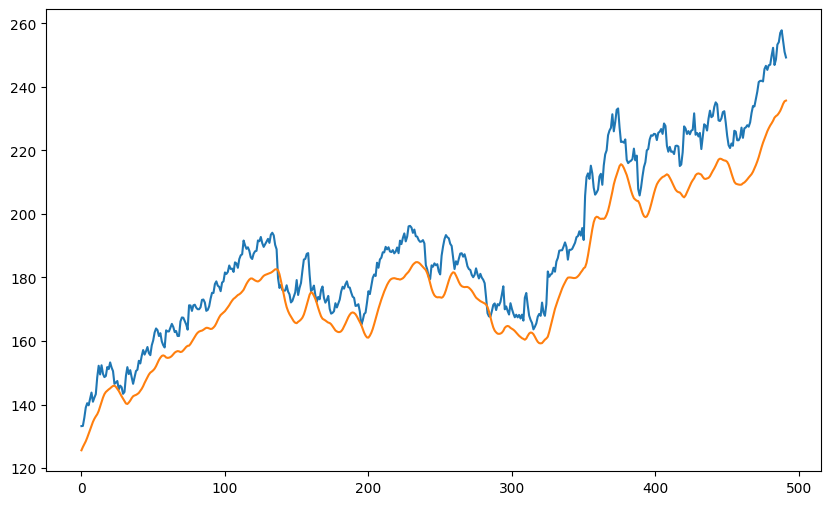

In [16]:

plt.figure(figsize=(10,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predicted_price, label="Predicted Price")
plt.title(f"{stock_symbol} Stock Price Prediction")
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
   Model Evaluation 
</center></p></h1>

In [17]:

mae = mean_absolute_error(y_test_actual, predicted_price)
mse = mean_squared_error(y_test_actual, predicted_price)
print(f"Mean Squared Error (MSE): {mse}")
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, predicted_price)


print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 142.257254693837
Mean Absolute Error (MAE): 10.66589628390182
Mean Squared Error (MSE): 142.257254693837
Root Mean Squared Error (RMSE): 11.927164570585795
R-squared (R²): 0.8052870908586733
